In [1]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
from scipy.optimize import dual_annealing
from cobra import Model as CobraModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', 
                        message='DataFrame is highly fragmented', 
                        category=pd.errors.PerformanceWarning)
import seaborn as sns
import matplotlib.colors as mcolors
from itertools import combinations
import ast
from matplotlib.colors import ListedColormap
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)
import os
from collections import Counter
from collections import defaultdict
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
import matplotlib.cm as cm

In [2]:
#import simoff input: model, qualitative criteria, input reactions
%store -r constrained_678
model = constrained_678 #late exponential CHO model: https://doi.org/10.1002/bit.28982

late_criteria = {
    "ICproduct_TRANSLATION_protein": 1,   # IgG secretion (positive flux)
    "biomass_cho_prod": 1,   # Biomass production - i.e. cells are growing (positive flux)
    "EX_nh4(e)": -1,  # Ammonia uptake (negative flux)
    "EX_lac_L(e)": -1   # Lactate uptake (negative flux)
}

input_reactions = ['ICproduct_TRANSLATION_protein','biomass_cho_prod','EX_nh4(e)','EX_lac_L(e)','EX_glc(e)','EX_gln_L(e)'] #chosen since cells are evolved to optimise these phenotypes

In [4]:
#import simoff and visualisation functions (final version of simoff is on github)
def annealing_2(
    model,
    objective_reactions,
    qualitative_constraints,
    bounds=None,
    max_iter=1000,
    initialtemp=5230,
    maxfun=10000000
):
    import numpy as np
    import pandas as pd
    import cobra
    from cobra.io import read_sbml_model
    from scipy.optimize import dual_annealing
    from cobra import Model as CobraModel
    import matplotlib.pyplot as plt
    import math
    import warnings
    warnings.filterwarnings('ignore', 
                           message='DataFrame is highly fragmented', 
                           category=pd.errors.PerformanceWarning)

    # --- Input checks ---
    if not isinstance(model, CobraModel):
        raise TypeError("Model must be a cobra.Model instance")
    if not isinstance(objective_reactions, list):
        raise TypeError("objective_reactions must be a list of reaction IDs")
    if not isinstance(qualitative_constraints, dict):
        raise TypeError("qualitative_constraints must be a dictionary")
        
    invalid_values = {k: v for k, v in qualitative_constraints.items() if v not in {-1, 0, 1}}
    if invalid_values:
        raise ValueError(f"Invalid reaction direction values: {invalid_values}")

    # --- Allow uptake if needed ---
    for k, v in qualitative_constraints.items():
        if v == -1 and not model.reactions.get_by_id(k).reversibility:
            model.reactions.get_by_id(k).lower_bound = -1000
            print(f"Updated bounds for {k} to allow uptake")

    print(f"\nOptimisation: fitting objective(s) {objective_reactions} "
          f"to match {len(qualitative_constraints)} qualitative constraints")

    if bounds is None:
        bounds = [(-1, 1)] * len(objective_reactions)

    selected_rxns = list(qualitative_constraints.keys())
    results_log = []
    agreement_matrix = {}

    # variable to store early stop result
    early_stop_data = None

    # --- Objective evaluation ---
    def evaluate_solution(c_raw):
        nonlocal early_stop_data

        # normalize so abs sum = 1
        if np.sum(np.abs(c_raw)) == 0:
            c = np.zeros_like(c_raw)
        else:
            c = c_raw / np.sum(np.abs(c_raw))

        # set objective coefficients
        for i, rxn_id in enumerate(objective_reactions):
            model.reactions.get_by_id(rxn_id).objective_coefficient = c[i]

        solution = model.optimize()

        flux_dict = {}
        agreement_dict = {}
        if solution is None:
            accuracy = 0.0
            mismatch_count = len(selected_rxns)
            for rxn_id in selected_rxns:
                flux_dict[rxn_id] = None
                agreement_dict[rxn_id] = 0
        else:
            fluxes = solution.fluxes[selected_rxns]
            expected = np.array([qualitative_constraints[r] for r in selected_rxns])
            rounded_fluxes = np.where(np.abs(fluxes) < 1e-6, 0, np.sign(fluxes).astype(int))
            mismatch_count = np.count_nonzero(rounded_fluxes != expected)
            accuracy = 1 - (mismatch_count / len(expected))
            flux_dict = dict(zip(selected_rxns, fluxes))
            agreement_dict = {rxn_id: int(round_f == exp)
                              for rxn_id, round_f, exp in zip(selected_rxns, rounded_fluxes, expected)}

        results_log.append({'coefficients': c.tolist(), 'accuracy': accuracy, 'fluxes': flux_dict})
        agreement_matrix[len(results_log) - 1] = agreement_dict

        # 🟢 Early stop if perfect accuracy
        if accuracy == 1.0:
            early_stop_data = (dict(zip(objective_reactions, c)), accuracy)
            raise SystemExit  # clean exit

        return 1 - accuracy

    # --- Auto temperature ---
    if initialtemp == 'auto':
        random_costs = []
        for _ in range(20):
            rand_coeffs = np.random.uniform(-1, 1, len(objective_reactions))
            cost = evaluate_solution(rand_coeffs)
            random_costs.append(cost)
        avg_delta_e = np.mean([abs(a - b) for a, b in zip(random_costs[:-1], random_costs[1:])])
        initialtemp = max(1.0, avg_delta_e / -math.log(1.0))
        print(f"Estimated initial temperature: {initialtemp:.2f}")

    # --- Run annealing with graceful early stop ---
    try:
        result = dual_annealing(
            evaluate_solution,
            bounds,
            maxiter=max_iter,
            initial_temp=initialtemp,
            maxfun=maxfun
        )
    except SystemExit:
        if early_stop_data is not None:
            coeffs, acc = early_stop_data
            print("\n🎯 Perfect 100% accuracy achieved!")
            print("Optimal Coefficients:", coeffs)
            log_df = pd.DataFrame(results_log)
            agreement_df = pd.DataFrame.from_dict(agreement_matrix, orient='index').T
            return coeffs, acc, log_df, None, agreement_df

    # --- If not perfect, finalize results ---
    if np.sum(np.abs(result.x)) == 0:
        scaled_coeffs = np.zeros_like(result.x)
    else:
        scaled_coeffs = result.x / np.sum(np.abs(result.x))

    for i, rxn_id in enumerate(objective_reactions):
        model.reactions.get_by_id(rxn_id).objective_coefficient = scaled_coeffs[i]

    solution = model.optimize()
    fluxes = solution.fluxes[selected_rxns]
    expected = np.array([qualitative_constraints[r] for r in selected_rxns])
    rounded_fluxes = np.where(np.abs(fluxes) < 1e-6, 0, np.sign(fluxes).astype(int))
    accuracy = 1 - (np.count_nonzero(rounded_fluxes != expected) / len(expected))

    # --- Logging ---
    log_df = pd.DataFrame(results_log)
    agreement_df = pd.DataFrame.from_dict(agreement_matrix, orient='index').T

    # --- Convergence plot ---
    #sampled_df = log_df.iloc[::10]
    #fig, ax = plt.subplots(figsize=(8, 4))
    #ax.plot(sampled_df.index, sampled_df['accuracy'], marker='o', linestyle='-', color='black')
    #ax.set_xlabel('Iteration')
    #ax.set_ylabel('Accuracy')
    #ax.set_title('Accuracy Over Time (Every 10th Evaluation)')
    #ax.grid(True)

    print("\nOptimization complete.")
    print("Optimal Coefficients:", dict(zip(objective_reactions, scaled_coeffs)))
    print(f"Final Accuracy: {accuracy:.2%}")

    return dict(zip(objective_reactions, scaled_coeffs)), accuracy, log_df, agreement_df

def plot_agreement_heatmaps(function_result, num_columns=100): #function_result: the result of optimize_objective_from_qualitative_criteria_agreement function
    """
    Plots heatmaps of agreement (binary 0/1) for the first and last `num_columns` iterations.

    Parameters:
        agreement_df (pd.DataFrame): DataFrame with reaction IDs as rows and iteration steps as columns.
        num_columns (int): Number of columns (iterations) to plot per subplot (default: 100).
    """
    
    agreement_df = function_result[3]
    id_to_name = {rxn.id: rxn.name for rxn in model.reactions}
    agreement_df.index = agreement_df.index.map(lambda rid: id_to_name.get(rid, rid))  # fallback to ID if name missing
    num_cols = agreement_df.shape[1]
    cols_to_plot = min(num_columns, num_cols)

    first_chunk = agreement_df.iloc[:, :cols_to_plot]
    last_chunk = agreement_df.iloc[:, -cols_to_plot:]

    # Define custom colormap
    cmap = mcolors.ListedColormap(["#d63384", "#20c997"])  # red for 0, green for 1
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create subplots
    fig_height = max(6, len(agreement_df) * 0.4)
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(cols_to_plot / 4, fig_height))

    # Plot first chunk
    sns.heatmap(
        first_chunk,
        ax=axes[0],
        cmap=cmap,
        norm=norm,
        cbar=False,
        linewidths=0.2,
        linecolor='white',
        square=False,
        xticklabels=max(1, cols_to_plot // 10),
        yticklabels=True
    )
    axes[0].set_title(f"First {cols_to_plot} Iterations")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Reaction ID")

    # Plot last chunk
    sns.heatmap(
        last_chunk,
        ax=axes[1],
        cmap=cmap,
        norm=norm,
        cbar=False,
        linewidths=0.2,
        linecolor='white',
        square=False,
        xticklabels=max(1, cols_to_plot // 10),
        yticklabels=True
    )
    axes[1].set_title(f"Last {cols_to_plot} Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Reaction ID")

    plt.tight_layout()
    plt.show()

def extract_and_plot_coefficients(function_result, step=10): #function_result: the result of optimize_objective_from_qualitative_criteria_agreement function
    # Get reaction IDs from the first iteration
    reaction_ids = list(function_result[0].keys())
    
    # Initialize dictionary to store coefficients for each reaction
    coeff_dict = {rid: [] for rid in reaction_ids}

    # Collect coefficients from each iteration
    for row in function_result[2].iloc[:, 0]:
        for i, rid in enumerate(reaction_ids):
            coeff_dict[rid].append(row[i])

    # Plotting
    num_reactions = len(reaction_ids)
    num_rows = (num_reactions + 1) // 2
    fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 4 * num_rows))
    axes = axes.flatten()

    x_axis = list(range(0, len(function_result[2]), step))

    colors = ['black', 'blue', 'red', 'green', 'purple', 'brown', 'orange', 'cyan']

    for i, rid in enumerate(reaction_ids):
        ax = axes[i]
        ax.plot(x_axis, coeff_dict[rid][::step], marker='o', linestyle='-', color=colors[i % len(colors)])
        reaction_name = model.reactions.get_by_id(rid).name
        ax.set_title(f'{rid}: {reaction_name}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Coefficient in objective function')
        ax.grid(True)
        ax.axhline(0, color='orange', linestyle='--', linewidth=2)
        ax.set_ylim(-1, 1)

    # Hide any unused subplots
    for j in range(num_reactions, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [5]:
#list all possible combinations of the input reactions
all_combos = []
for r in range(1, len(input_reactions) + 1):
    all_combos.extend(combinations(input_reactions, r))
    all_combos = [list(t) for t in all_combos]
print(f"There are {len(all_combos)} possible combinations of objectives.\n")

There are 63 possible combinations of objectives.



In [57]:
#run simoff and save result
#optimal result which came out was {'ICproduct_TRANSLATION_protein': np.float64(0.9452826634320092),'biomass_cho_prod': np.float64(0.0547173365679908)}
%%time
results = {}
for combo in all_combos:
    if len(combo) > 1:
        results[tuple(combo)] = annealing_2(model, combo, late_criteria, bounds=None, max_iter=300,initialtemp=50, maxfun=5000)
        if results[tuple(combo)][1] == 1.0:
            print(print("\n🎯 Perfect 100% accuracy achieved, so dropped out of loop"))
            break
#can run through the combinations outside of the combinations function, which is slightly quicker and gives similar results


Optimisation: fitting objective(s) ['ICproduct_TRANSLATION_protein', 'biomass_cho_prod'] to match 4 qualitative constraints

🎯 Perfect 100% accuracy achieved, so dropped out of loop
None
CPU times: total: 1.84 s
Wall time: 20.5 s


### Figure 6a

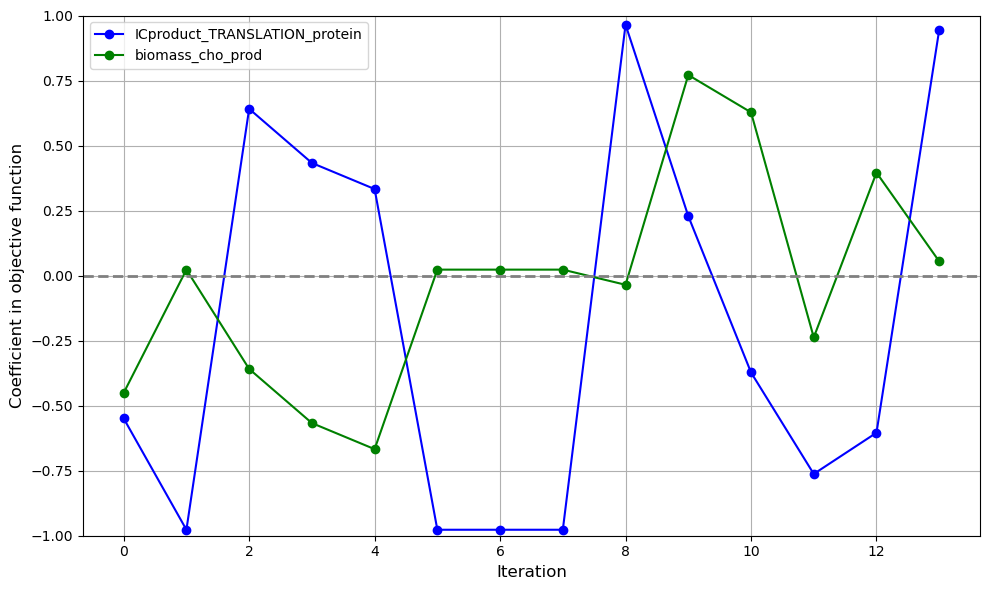

In [87]:
#since the original solution shown in figure 6a was generated elsewhere, import it here
coeff_series = results['ICproduct_TRANSLATION_protein',
  'biomass_cho_prod'][2]['coefficients']

# Convert series to a proper 2D array
coeff_array = np.vstack(coeff_series.values)

# Plot every 10th point
step = 1
coeff_array_step = coeff_array[::step]
x_axis = np.arange(len(coeff_array))[::step]

reaction_labels = ['ICproduct_TRANSLATION_protein',
  'biomass_cho_prod']
colors = ['blue','green']

plt.figure(figsize=(10, 6))

# Plot the two coefficient curves
for i in range(2):
    plt.plot(
        x_axis,
        coeff_array_step[:, i],
        marker='o',
        linestyle='-',
        linewidth=1.5,
        color=colors[i],
        label=reaction_labels[i]
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=2)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Coefficient in objective function", fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-1, 1)
plt.tight_layout()
#plt.savefig('cho_combinations_late_4.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 6b

In [5]:
#print results for simoff column of figure 6b
results['ICproduct_TRANSLATION_protein','biomass_cho_prod'][2]['fluxes']

ICproduct_TRANSLATION_protein 6.271329627483619e-05
biomass_cho_prod 0.0020123131513649604
EX_nh4(e) 0.13314322243299045
EX_lac_L(e) 0.02298236936146294


In [6]:
#this is the control data for the table to compare absolute flux predictions
experimental_fluxes = {'biomass_cho_prod':[0.389603436,0.387968697,0.415823572,0.798441296,0.330042824,0.352084182,
                              0.422441519,0.417135113,0.393464278,-0.026775809,0.736742289,0.333249031,
                              0.243531691,0.167204988,0.371955397,0.339347745,-0.051891089,0.286056855],
                    'ICproduct_TRANSLATION_protein':[0.0000242777,0.0000245681,0.0000242784,0.0000216538,0.0000238745,0.0000242047,
                           0.0000258268,0.000026511,0.0000268954,0.0000241365,0.0000226874,0.0000260239],
                    'EX_nh4(e)':[-0.012978488,-0.014578577,0.007868785,0.00348815,-0.10477789,-0.013760917,
                           -0.014944994,-0.010676486,-0.014070916,-0.007595494,0.035630288,-0.010655738,
                           0.00475468,0.002951519,-0.006542142,-0.007324107,0.000612444,0.006444505],
                    'EX_lac_L(e)':[0.07078951,0.052416301,0.093596572,0.09241039,0.102084868,0.094567197,
                          -0.056561822,-0.04591698,0.007007069,-0.021080702,-0.029915255,-0.035527413,
                           -0.096203392,-0.093553083,-0.101896217,-0.097832833,-0.097931067,-0.110433878]}

exp_means = {k: np.mean(v) for k,v in experimental_fluxes.items()}
exp_ranges = {k: np.max(v)-np.min(v) for k,v in experimental_fluxes.items()}

# Define objectives
atp_objective = {model.reactions.get_by_id('ATPS4m'):1}
igg_objective = {model.reactions.get_by_id('ICproduct_TRANSLATION_protein'):1}
biomass_objective = {model.reactions.get_by_id('biomass_cho_prod'):1}
split_objective = {
    model.reactions.get_by_id('ICproduct_TRANSLATION_protein'):0.5,
    model.reactions.get_by_id('biomass_cho_prod'):0.5
}

tests = {
    "atp": atp_objective,
    "igg": igg_objective,
    "biomass": biomass_objective,
    "split": split_objective
}
for key,value in tests.items():
    print('Testing:',key)
    with model:
            model.objective = value
            solution = model.optimize()
    for k,v in late_criteria.items():
        print('Experimental:',k,v)
        print('Model:',solution.fluxes[k])
    print('')

Testing: atp
Experimental: ICproduct_TRANSLATION_protein 1
Model: 6.505815058680408e-05
Experimental: biomass_cho_prod 1
Model: 0.0015114298752107647
Experimental: EX_nh4(e) -1
Model: 0.13262681877455448
Experimental: EX_lac_L(e) -1
Model: 0.02304458945992867

Testing: igg
Experimental: ICproduct_TRANSLATION_protein 1
Model: 7.741856387628713e-05
Experimental: biomass_cho_prod 1
Model: 0.0
Experimental: EX_nh4(e) -1
Model: 0.13487648299601168
Experimental: EX_lac_L(e) -1
Model: 0.023253479407772257

Testing: biomass
Experimental: ICproduct_TRANSLATION_protein 1
Model: 6.121420756219195e-05
Experimental: biomass_cho_prod 1
Model: 0.002012313151364959
Experimental: EX_nh4(e) -1
Model: 0.13277333338157643
Experimental: EX_lac_L(e) -1
Model: 0.022976373006612746

Testing: split
Experimental: ICproduct_TRANSLATION_protein 1
Model: 6.271329627483593e-05
Experimental: biomass_cho_prod 1
Model: 0.0020123131513649604
Experimental: EX_nh4(e) -1
Model: 0.13163187210597263
Experimental: EX_lac_L(e

### Figure 6c, d, e , f and g

In [106]:
#generate knockout dataframes for SIMOFF optimisation and all control objectives
#define controls to be compared against
igg_objective = {model.reactions.get_by_id('ICproduct_TRANSLATION_protein'):1}
biomass_objective = {model.reactions.get_by_id('biomass_cho_prod'):1}
equal_split_igg_biomass_objective = {model.reactions.get_by_id('ICproduct_TRANSLATION_protein'):0.5,
                                     model.reactions.get_by_id('biomass_cho_prod'):0.5}
complex_v_objective = {model.reactions.get_by_id('ATPS4m'):1} #final component in oxphos: atp synthase
annealing_objective = {model.reactions.get_by_id('ICproduct_TRANSLATION_protein'):0.9452826634320092,
                      model.reactions.get_by_id('biomass_cho_prod'):0.0547173365679908} #simoff objective for late exponential cho
objectives_to_explore = [annealing_objective,igg_objective, biomass_objective, split_objective,
                         complex_v_objective]
genes = [g.id for g in model.genes]  # list of gene IDs
entire_list_of_dfs = []

for o in objectives_to_explore:
    print('Running:',o)
    df = pd.DataFrame()
    df['gene'] = genes
    ko_growths = []
    ko_iggs = []
    grRatio = []
    iggRatio = []

    # Get wild-type fluxes under current objective
    with model:
        model.objective = o
        solution = model.optimize()
        wt_growth = solution.fluxes['biomass_cho_prod']
        wt_igg = solution.fluxes['ICproduct_TRANSLATION_protein']

    for g in genes:
        with model:
            # Knock out all reactions associated with the gene
            gene_obj = model.genes.get_by_id(g)
            for r in gene_obj.reactions:
                r.bounds = (0, 0)

            # Optimize under the current objective
            model.objective = o
            ko_solution = model.optimize()
            ko_growth = ko_solution.fluxes['biomass_cho_prod']
            ko_igg = ko_solution.fluxes['ICproduct_TRANSLATION_protein']

            # Append values
            ko_growths.append(ko_growth)
            ko_iggs.append(ko_igg)
            grRatio.append(ko_growth / wt_growth if wt_growth != 0 else 0)
            iggRatio.append(ko_igg / wt_igg if wt_igg != 0 else 0)

    # Add columns to the dataframe
    df['growth'] = ko_growths
    df['igg'] = ko_iggs
    df['grRatio'] = grRatio
    df['iggRatio'] = iggRatio
    df['objective'] = str(o)  # optional: track which objective

    entire_list_of_dfs.append(df)

# Concatenate results for all objectives
entire_deletion_df = pd.concat(entire_list_of_dfs, ignore_index=True)

# Example: view first rows
print(entire_deletion_df.head())

Running: {<Reaction ICproduct_TRANSLATION_protein at 0x191a6d95810>: 0.9452826634320092, <Reaction biomass_cho_prod at 0x191a7f50190>: 0.0547173365679908}
Running: {<Reaction ICproduct_TRANSLATION_protein at 0x191a6d95810>: 1}
Running: {<Reaction biomass_cho_prod at 0x191a7f50190>: 1}
Running: {<Reaction ICproduct_TRANSLATION_protein at 0x191a6d95810>: 0.5, <Reaction biomass_cho_prod at 0x191a7f50190>: 0.5}
Running: {<Reaction ATPS4m at 0x191a63c0bd0>: 1}
        gene    growth       igg  grRatio  iggRatio  \
0  100771382  0.002012  0.000063      1.0       1.0   
1  100763954  0.002012  0.000063      1.0       1.0   
2  100762926  0.002012  0.000063      1.0       1.0   
3  100762635  0.002012  0.000063      1.0       1.0   
4  100751853  0.002012  0.000063      1.0       1.0   

                                           objective  
0  {<Reaction ICproduct_TRANSLATION_protein at 0x...  
1  {<Reaction ICproduct_TRANSLATION_protein at 0x...  
2  {<Reaction ICproduct_TRANSLATION_protein 

In [107]:
#separate out and save the individual objective dataframes
annealing_df = entire_deletion_df[:len(model.genes)]
igg_df = entire_deletion_df[len(model.genes):len(model.genes)*2]
biomass_df = entire_deletion_df[len(model.genes)*2:len(model.genes)*3]
split_df = entire_deletion_df[len(model.genes)*3:len(model.genes)*4]
atp_df = entire_deletion_df[len(model.genes)*4:len(model.genes)*5]

In [7]:
#dataframes were generated in another notebook originally so loaded in here to neat notebook
%store -r annealing_df
%store -r igg_df
%store -r biomass_df
%store -r split_df
%store -r atp_df

In [8]:
#here, a target has been defined as one that increases growth, in line with validation dataset: https://doi.org/10.1016/j.crmeth.2021.100062
#supp table 4: https://doi.org/10.1016/j.crmeth.2021.100062
df = annealing_df
annealing_targets = df[(df["grRatio"] < 0.99)]
annealing_not_targets = df[(df["grRatio"] >= 0.99)]
print(len(annealing_targets),'annealing targets')

df = atp_df
atp_targets = df[(df["grRatio"] < 0.99)]
atp_not_targets = df[(df["grRatio"] >= 0.99)]
print(len(atp_targets),'atp targets')

df = split_df
split_targets = df[(df["grRatio"] < 0.99)]
split_not_targets = df[(df["grRatio"] >= 0.99)]
print(len(split_targets),'split targets')

df = biomass_df
biomass_only_targets = df[(df["grRatio"] < 0.99)]
biomass_only_not_targets = df[(df["grRatio"] >= 0.99)]
print(len(biomass_only_targets),'biomass targets')

df = igg_df
igg_targets = df[(df["grRatio"] < 0.99)]
igg_not_targets = df[(df["grRatio"] >= 0.99)]
print(len(igg_targets),'igg targets')

exp = pd.read_csv(r'cho_essentiality.csv') #this is from https://www.cell.com/cell-reports-methods/fulltext/S2667-2375(21)00110-7
exp_targets = exp[exp['essential']==0]
exp_not_targets = exp[exp['essential']==1]
exp_targets_ids = exp_targets['knockout'].astype('Int64').astype(str)
exp_not_targets_ids = exp_not_targets['knockout'].astype('Int64').astype(str)

genes = []
for g in model.genes:
    genes.append(g.id)
print('There are',len(genes),'genes total in model')
print('There are',len(exp_targets_ids)+len(exp_not_targets_ids),'genes in experimental dataset')
overlap = []
for e in exp_targets_ids:
    if e in genes:
        overlap.append(e)
for e in exp_not_targets_ids:
    if e in genes:
        overlap.append(e)
print('There are',len(overlap),'genes in both experimental dataset and model')
#work out why this isn't quite working, then plot as matrix and narrow down targets to those that increase igg and do a second validation of these to differentiate annealing, split and biomass...

217 annealing targets
2432 atp targets
217 split targets
217 biomass targets
2441 igg targets
There are 2441 genes total in model
There are 2290 genes in experimental dataset
There are 2288 genes in both experimental dataset and model


In [35]:
#save targets/not targets into CSV files so they can be studied outside of notebook
targets_df = pd.read_csv('targets_151225.csv')
not_targets_df = pd.read_csv('not_targets_151225.csv')

In [36]:
#generate data for confusion matrices

#generate confusion matrices for the performance of each objective function
cols = ["SIMOFF", "ATP", "IgG", "Biomass", "Split"]

# Extract sets of experimental true positives and true negatives
exp_targets = set(targets_df["Experimental"].dropna().astype(int).astype(str))
exp_not_targets = set(not_targets_df["Experimental"].dropna().astype(int).astype(str))

# Combined experimental set = allowed genes
exp_all = exp_targets | exp_not_targets

conf_matrices = {}

for col in cols:
    # predicted TARGETS
    pred_targets = set(targets_df[col].dropna().astype(int).astype(str))

    # predicted NOT-TARGETS
    pred_not_targets = set(not_targets_df[col].dropna().astype(int).astype(str))

    # restrict to genes in experimental dataset only
    pred_targets &= exp_all
    pred_not_targets &= exp_all

    # compute confusion matrix components
    TP = len(pred_targets & exp_targets)
    FP = len(pred_targets & exp_not_targets)
    FN = len(pred_not_targets & exp_targets)
    TN = len(pred_not_targets & exp_not_targets)

    conf_matrices[col] = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }

print(conf_matrices)

plt.rcParams["font.family"] = "Arial"


# Folder to save images
save_folder = "confusion_matrices"
os.makedirs(save_folder, exist_ok=True)

plt.rcParams["font.family"] = "Arial"

for col, scores in conf_matrices.items():

    matrix = np.array([
        [scores["TP"], scores["FN"]],
        [scores["FP"], scores["TN"]]
    ])

    plt.figure(figsize=(5,4))
    sns.heatmap(
        matrix,
        annot=False,
        cmap="Blues",
        cbar=False,
        xticklabels=["Actual Target", "Actual Not Target"],
        yticklabels=["Predicted Target", "Predicted Not Target"]
    )

    plt.title(f"Confusion Matrix – {col}", fontfamily="Arial")
    plt.xlabel("Experimental", fontfamily="Arial")
    plt.ylabel("Prediction", fontfamily="Arial")
    plt.xticks(fontfamily="Arial")
    plt.yticks(fontfamily="Arial")

    # Save figure
    save_path = os.path.join(save_folder, f"confusion_matrix_{col}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.close()

{'SIMOFF': {'TP': 113, 'FP': 104, 'FN': 279, 'TN': 1792}, 'ATP': {'TP': 392, 'FP': 1887, 'FN': 0, 'TN': 9}, 'IgG': {'TP': 392, 'FP': 1896, 'FN': 0, 'TN': 0}, 'Biomass': {'TP': 113, 'FP': 104, 'FN': 279, 'TN': 1792}, 'Split': {'TP': 113, 'FP': 104, 'FN': 279, 'TN': 1792}}


In [37]:
#calculate specificity: ability to find the true negatives in validation dataset
#true negative/(true negative + false positive)
print('Specificities of objective functions:')
print('SIMOFF:',conf_matrices['SIMOFF']['TN']/(conf_matrices['SIMOFF']['TN']+conf_matrices['SIMOFF']['FP']))
print('ATP:',conf_matrices['ATP']['TN']/(conf_matrices['ATP']['TN']+conf_matrices['ATP']['FP']))
print('IgG:',conf_matrices['IgG']['TN']/(conf_matrices['IgG']['TN']+conf_matrices['IgG']['FP']))
print('Biomass:',conf_matrices['Biomass']['TN']/(conf_matrices['Biomass']['TN']+conf_matrices['Biomass']['FP']))
print('Split:',conf_matrices['Split']['TN']/(conf_matrices['Split']['TN']+conf_matrices['Split']['FP']))

#calculate sensitivity: ability to find the true positives in validation dataset
#true positive/(true positive + false negative)
print('Sensitivities of objective functions:')
print('SIMOFF:',conf_matrices['SIMOFF']['TP']/(conf_matrices['SIMOFF']['TP']+conf_matrices['SIMOFF']['FN']))
print('ATP:',conf_matrices['ATP']['TP']/(conf_matrices['ATP']['TP']+conf_matrices['ATP']['FN']))
print('IgG:',conf_matrices['IgG']['TP']/(conf_matrices['IgG']['TP']+conf_matrices['IgG']['FN']))
print('Biomass:',conf_matrices['Biomass']['TP']/(conf_matrices['Biomass']['TP']+conf_matrices['Biomass']['FN']))
print('Split:',conf_matrices['Split']['TP']/(conf_matrices['Split']['TP']+conf_matrices['Split']['FN']))

Specificities of objective functions:
SIMOFF: 0.9451476793248945
ATP: 0.004746835443037975
IgG: 0.0
Biomass: 0.9451476793248945
Split: 0.9451476793248945
Sensitivities of objective functions:
SIMOFF: 0.288265306122449
ATP: 1.0
IgG: 1.0
Biomass: 0.288265306122449
Split: 0.288265306122449


In [454]:
#statistics for flux cone learning, for comparison (https://doi.org/10.1038/s41467-025-63436-9)
print('S. Cerevisiae:')
print('Sensitivity:',8/(8+23))
print('Specificity:',190/(190+2))

print('Chinese Hamster Ovary:')
print('Sensitivity:',17/(17+61))
print('Specificity:',367/(367+12))
#so SIMOFF is more sensitive but less specific than FCL for both yeast and cho FCL examples but in very similar range

S. Cerevisiae:
Sensitivity: 0.25806451612903225
Specificity: 0.9895833333333334
Chinese Hamster Ovary:
Sensitivity: 0.21794871794871795
Specificity: 0.9683377308707124


### Figure 6h

In [47]:
#redefine targets to those that improve IgG, so that I can distinguish knockout datasets
df = annealing_df
annealing_targets = df[(df["iggRatio"] > 1.01) & (df['growth']>0)]
print(len(annealing_targets))
df = atp_df
atp_targets = df[(df["iggRatio"] > 1.01) & (df['growth']>0)]
print(len(atp_targets))
df = split_df
split_targets = df[(df["iggRatio"] > 1.01) & (df['growth']>0)]
print(len(split_targets))
df = biomass_df
biomass_only_targets = df[(df["iggRatio"] > 1.01) & (df['growth']>0)]
print(len(biomass_only_targets))
df = igg_df
igg_targets = df[(df["iggRatio"] > 1.01) & (df['growth']>0)]
print(len(igg_targets))

33
16
21
9
0


In [135]:
#how much do these knockouts improve IgG?
print('annealing:',max(annealing_targets['iggRatio']))
print('atp:',max(atp_targets['iggRatio']))
print('biomass:',max(biomass_only_targets['iggRatio']))
print('split:',max(split_targets['iggRatio']))

annealing: 1.234484048438576
atp: 1.0947872801818241
biomass: 1.1033441649437226
split: 1.234484048438565


In [ ]:
#find intersection of the targets that when knocked out increase IgG
annealing_targets = annealing_targets['gene'].to_list()
atp_targets = atp_targets['gene'].to_list()
split_targets = split_targets['gene'].to_list()
biomass_targets = biomass_only_targets['gene'].to_list()

set1 = set(annealing_targets)
set2 = set(atp_targets)
set3 = set(split_targets)
set4 = set(biomass_targets)

intersection_1234 = set1 & set2 & set3 & set4
print("Intersection of all four:", intersection_1234)

inter12 = set1 & set2
inter23 = set2 & set3
inter13 = set1 & set3
inter14 = set1 & set4
inter24 = set2 & set4
inter34 = set3 & set4
inter123 = set1 & set2 & set3
inter124 = set1 & set2 & set4
inter234 = set2 & set3 & set4
inter134 = set1 & set3 & set4
inter1234 = set1 & set2 & set3 & set4

print("1 ∩ 2:", inter12)
print("2 ∩ 3:", inter23)
print("1 ∩ 3:", inter13)
print("1 ∩ 4:", inter14)
print("2 ∩ 4:", inter24)
print("3 ∩ 4:", inter34)
print("1 ∩ 2 ∩ 3:", inter123)
print("1 ∩ 2 ∩ 4:", inter124)
print("2 ∩ 3 ∩ 4:", inter234)
print("1 ∩ 3 ∩ 4:", inter134)
print("1 ∩ 2 ∩ 3 ∩ 4:", inter1234)

In [91]:
#identify which subsystems contain the annealing knockout targets
subsystem_counts = Counter()

for g in annealing_targets['gene']:
    gene_obj = model.genes.get_by_id(g)
    
    for r in gene_obj.reactions:
        subsystem_counts[r.subsystem] += 1

# Convert to a regular dict if you want
subsystem_counts = dict(subsystem_counts)

#are particular subsystems enriched in the target list
model_subsystem_counts = Counter()

for g in model.genes:
    gene_obj = model.genes.get_by_id(g.id)
    
    for r in gene_obj.reactions:
        model_subsystem_counts[r.subsystem] += 1

# Convert to a regular dict if you want
model_subsystem_counts = dict(model_subsystem_counts)

total = []
for k,v in subsystem_counts.items():
    total.append(model_subsystem_counts[k])
sum_total = sum(total)

total_2 = []
for k,v in subsystem_counts.items():
    total_2.append(subsystem_counts[k])
sum_total_2 = sum(total_2)

expected_ratios = {}
for k,v in subsystem_counts.items():
    expected_ratios[k] = model_subsystem_counts[k]/sum_total
observed_ratios = {}
for k,v in subsystem_counts.items():
    observed_ratios[k] = subsystem_counts[k]/sum_total_2
enrichments = {}
for k,v in observed_ratios.items():
    enrichments[k] = observed_ratios[k]/expected_ratios[k]

for k,v in enrichments.items():
    print(k,v)

#chatgpt to see if I've worked this out right, or just do it on Excel

Glycerophospholipid, sphingolipid and inositol metabolism 1.058168632858383
Bile, eicosanoid and steroid metabolism 1.5857709203900139
Vitamin and cofactor metabolism 0.3690082902200337
Nucelotide metabolism 1.5333048936559204
Central carbon and energy metabolism 0.46808286331769544
Amino acid metabolism 0.0721019170340779
Biomass synthesis 2.9927060012999207


In [97]:
#Fisher exact test for subsystem enrichment of target genes from annealing knockout dataframe

# --- Reactions associated with target genes ---
target_rxns = set()
for g in annealing_targets['gene']:
    gene = model.genes.get_by_id(g)
    for r in gene.reactions:
        target_rxns.add(r.id)

# --- All reactions by subsystem ---
subsystem_rxns = defaultdict(set)
for r in model.reactions:
    subsystem_rxns[r.subsystem].add(r.id)

# Totals
N = len(model.reactions)
n = len(target_rxns)

results = []

for subsystem, rxns in subsystem_rxns.items():
    K = len(rxns)
    k = len(rxns & target_rxns)

    if k == 0:
        continue  # nothing to test

    # Hypergeometric p-value (enrichment)
    pval = hypergeom.sf(k-1, N, K, n)

    enrichment = (k / n) / (K / N)

    results.append({
        "Subsystem": subsystem,
        "Target_rxns": k,
        "Subsystem_rxns": K,
        "Enrichment": enrichment,
        "p_value": pval
    })

df_enrichment = pd.DataFrame(results).sort_values("p_value")
print(df_enrichment)

df_enrichment["FDR"] = multipletests(
    df_enrichment["p_value"],
    method="fdr_bh"
)[1]

                                           Subsystem  Target_rxns  \
6                                  Biomass synthesis           14   
3  Glycerophospholipid, sphingolipid and inositol...           14   
2                              Nucelotide metabolism           13   
4            Bile, eicosanoid and steroid metabolism           10   
5               Central carbon and energy metabolism            1   
0                    Vitamin and cofactor metabolism            2   
1                              Amino acid metabolism            1   

   Subsystem_rxns  Enrichment       p_value  
6              47   34.320309  6.390377e-19  
3             289    5.581504  9.892441e-08  
2             288    5.200821  6.996148e-07  
4             212    5.434820  1.111921e-05  
5              93    1.238905  5.580932e-01  
0             217    1.061919  5.669991e-01  
1             381    0.302410  9.674647e-01  


In [98]:
df_enrichment

,Subsystem,Target_rxns,Subsystem_rxns,Enrichment,p_value,FDR
6,Biomass synthesis,14,47,34.320309,6.390377e-19,4.473264e-18
3,"Glycerophospholipid, sphingolipid and inositol...",14,289,5.581504,9.892441e-08,3.462354e-07
2,Nucelotide metabolism,13,288,5.200821,6.996148e-07,1.632435e-06
4,"Bile, eicosanoid and steroid metabolism",10,212,5.434820,1.111921e-05,1.945862e-05
5,Central carbon and energy metabolism,1,93,1.238905,5.580932e-01,6.614990e-01
0,Vitamin and cofactor metabolism,2,217,1.061919,5.669991e-01,6.614990e-01
1,Amino acid metabolism,1,381,0.302410,9.674647e-01,9.674647e-01


In [127]:
subsystems_list = []
for s in df_enrichment['Subsystem']:
    subsystems_list.append(s)
x_axis = ['Biomass synthesis',
 'Glycerophospholipid, \nsphingolipid and \ninositol metabolism',
 'Bile, eicosanoid \nand steroid metabolism',
 'Nucelotide metabolism',
 'Central carbon \nand energy metabolism',
 'Vitamin and \ncofactor metabolism',
 'Amino acid metabolism'] #printed the df_enrichment column, then copied and pasted here so that I could insert line breaks for axis below

C:\Users\p04121km\AppData\Local\Temp\ipykernel_2820\2962448867.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subsystems, rotation=45, ha="right")


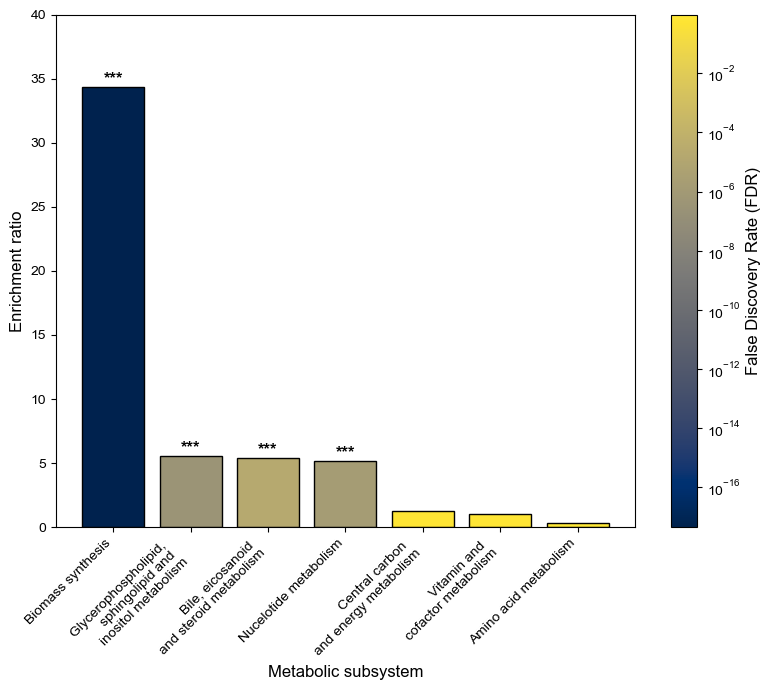

In [126]:
df_enrichment = df_enrichment.sort_values("Enrichment", ascending=False)

subsystems = x_axis
enrichment = df_enrichment["Enrichment"]
fdr = df_enrichment["FDR"]

# --- Significance stars based on FDR ---
def significance_stars(fdr):
    if fdr < 0.001:
        return "***"
    elif fdr < 0.01:
        return "**"
    elif fdr < 0.05:
        return "*"
    else:
        return ""

stars = [significance_stars(x) for x in fdr]

# --- Color mapping based on FDR ---
# Use log scale because FDR spans orders of magnitude
norm = mcolors.LogNorm(vmin=fdr.min(), vmax=fdr.max())
cmap = cm.cividis
colors = cmap(norm(fdr))

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.bar(
    subsystems,
    enrichment,
    color=colors,
    edgecolor="black"
)

# --- Add significance stars ---
for bar, star in zip(bars, stars):
    if star:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            star,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

# --- Labels and formatting ---
ax.set_ylabel("Enrichment ratio", fontsize=12)
ax.set_xlabel("Metabolic subsystem", fontsize=12)
ax.set_xticklabels(subsystems, rotation=45, ha="right")
ax.set_yticks(np.arange(0, max(enrichment) + 0.5, 0.5))
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 41, 5))

# --- Colorbar for FDR ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("False Discovery Rate (FDR)", fontsize=12)

plt.tight_layout()
plt.savefig("subsystem_enrichment_barplot.png", dpi=300, bbox_inches="tight")
plt.show()